In [33]:
import sympy as sp
from sympy import diff, Eq, solve, symbols
import matplotlib.pyplot as plt
import math
import numpy as np
import inspect
import random

In [94]:
def lagrange(f, g, k=0):
    f_var = list(inspect.signature(f_xyz).parameters)
    g_var = list(inspect.signature(g_xyz).parameters)

    f_variables = sp.symbols(" ".join(f_var))
    g_variables = sp.symbols(" ".join(g_var))

    f_function = f(*f_variables)
    g_function = g(*g_variables)

    variables = list(dict.fromkeys(f_variables + g_variables))
    equations = [Eq(g_function, k)]

    L = sp.symbols('L')
    
    for var in variables:
        f_grad = sp.diff(f_function, var)
        g_grad = sp.diff(g_function, var)
        equations.append(Eq(f_grad, L * g_grad))

    solutions = sp.solve(
    equations,
    [*variables, L],
    dict=True)

    outputs=[]
    for solution in solutions:
        outputs.append(f_function.subs(solution))

    if len(outputs) == 0:
        return "No solutions"
    
    max_output = max(outputs)
    min_output = min(outputs)

    max_solutions = []
    min_solutions = []

    for x in range(len(outputs)):
        if outputs[x] == max_output:
            ap = solutions[x]
            del ap[L]
            max_solutions.append(ap)
            

        if outputs[x] == min_output:
            ap = solutions[x]
            if L in ap:
                del ap[L]
            min_solutions.append(ap)
    

    print(f"Max: {max_output} at {max_solutions}")
    print(f"Min: {min_output} at {min_solutions}")
    
    return (max_output, min_output, max_solutions, min_solutions, variables)

In [119]:
def lagrange_grapher(
    f,
    g,
    k=0,
    which="max",
    solution_index=0,
    resolution=200
):
    (max_output, min_output, max_solutions, min_solutions, variables
    ) = lagrange(f, g, k)

    if len(variables) != 3:
        raise ValueError("This grapher requires exactly three variables.")

    x, y, z = variables

    # Pick max or min
    if which == "max":
        selected_output = max_output
        selected_solutions = max_solutions

    elif which == "min":
        selected_output = min_output
        selected_solutions = min_solutions

    else:
        raise ValueError("which must be 'max' or 'min'.")

    # Pick exactly one solution
    solution = selected_solutions[solution_index]

    x_point = float(sp.N(solution[x]))
    y_point = float(sp.N(solution[y]))
    z_point = float(sp.N(solution[z]))

    print("Graphing solution:", solution)
    print("Objective level:", selected_output)

    # Use ranges centered around this one solution
    x_values = np.linspace(
        x_point - 1,
        x_point + 1,
        resolution
    )

    y_values = np.linspace(
        y_point-1,
        y_point+1,
        resolution
    )

    X, Y = np.meshgrid(x_values, y_values)

    f_function = f(*variables)
    g_function = g(*variables)

    # Solve both surfaces for z
    f_z_options = sp.solve(
        sp.Eq(f_function, selected_output),
        z
    )

    g_z_options = sp.solve(
        sp.Eq(g_function, k),
        z
    )

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    
    def choose_matching_option(options, surface_name):
        for expression in options:
            # Calculate this branch's z-value at the solution's x and y
            branch_z_at_point = sp.simplify(
                expression.subs({
                    x: x_point,
                    y: y_point
                })
            )
    
            # Keep the branch whose z-value matches the solution's z-value
            if sp.simplify(branch_z_at_point - z_point) == 0:
                return expression
    
        raise ValueError(
            f"No branch of {surface_name} passes through {solution}."
        )
    
    
    f_z_expression = choose_matching_option(
        f_z_options,
        "the objective level set"
    )
    
    g_z_expression = choose_matching_option(
        g_z_options,
        "the constraint"
    )
    
        
    def make_Z(z_expression):
        z_numpy = sp.lambdify(
            (x, y),
            z_expression,
            "numpy"
        )

        with np.errstate(all="ignore"):
            Z = z_numpy(X, Y)

        if np.ndim(Z) == 0:
            Z = np.full(X.shape, Z)

        Z = np.broadcast_to(Z, X.shape)
        Z = np.asarray(Z, dtype=np.complex128)

        valid = (np.abs(Z.imag) < 1e-10) & np.isfinite(Z.real)

        return np.where(valid, Z.real, np.nan)

    
    F_Z = make_Z(f_z_expression)
    G_Z = make_Z(g_z_expression)
    
    ax.plot_surface(X, Y, F_Z, alpha=0.6, edgecolor="none")
    
    ax.plot_surface(X, Y, G_Z, alpha=0.35, edgecolor="none")
    
    ax.scatter(
        float(solution[x]),
        float(solution[y]),
        float(solution[z]),
        s=100
    )
    
    plt.show()

Max: 7*sqrt(2)/4 at [{x: 1/4, y: 1/4, z: 1/4}]
Min: 7*sqrt(2)/4 at [{x: 1/4, y: 1/4, z: 1/4}]
Graphing solution: {x: 1/4, y: 1/4, z: 1/4}
Objective level: 7*sqrt(2)/4


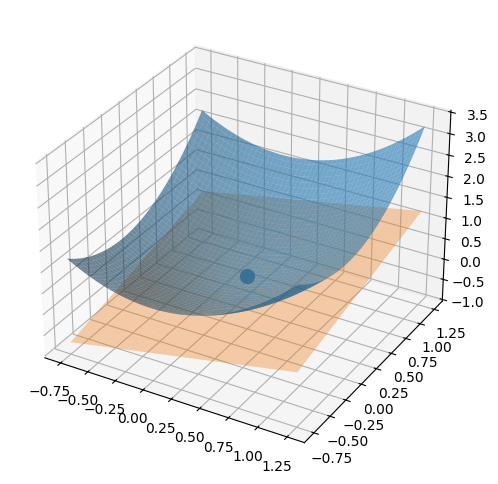

In [120]:
lagrange_grapher(f_xyz, g_xyz, which = "max", solution_index = 0, k=0)

In [116]:
def f_xyz(x,y,z):
    return (sp.sqrt(6-x**2 - y**2 + z))

def g_xyz(x,y,z):
    return (x + y - 2*z)

In [117]:
result = lagrange(f_xyz, g_xyz, 0)

print("Type:", type(result))
print("Length:", len(result))
print("Result:", result)

Max: 7*sqrt(2)/4 at [{x: 1/4, y: 1/4, z: 1/4}]
Min: 7*sqrt(2)/4 at [{x: 1/4, y: 1/4, z: 1/4}]
Type: <class 'tuple'>
Length: 5
Result: (7*sqrt(2)/4, 7*sqrt(2)/4, [{x: 1/4, y: 1/4, z: 1/4}], [{x: 1/4, y: 1/4, z: 1/4}], [x, y, z])
